# REGRESSÃO LINEAR MÚLTIPLA                     
#### EXEMPLO 2

1 - Importação dos pacotes

In [54]:
import pandas as pd # manipulação de dados em formato de dataframe
import numpy as np # operações matemáticas
import seaborn as sns # visualização gráfica
import matplotlib.pyplot as plt # visualização gráfica
import plotly.graph_objects as go # gráficos 3D
from scipy.stats import pearsonr # correlações de Pearson
import statsmodels.api as sm # estimação de modelos
from statsmodels.iolib.summary2 import summary_col # comparação entre modelos
from sklearn.preprocessing import LabelEncoder # transformação de dados
import pingouin as pg # outro modo para obtenção de matrizes de correlações
from statstests.process import stepwise # procedimento Stepwise
from statstests.tests import shapiro_francia # teste de Shapiro-Francia
from scipy.stats import boxcox # transformação de Box-Cox
from scipy.stats import norm # para plotagem da curva normal
from scipy import stats # utilizado na definição da função 'breusch_pagan_test'
import pygame # reprodução de sons

import warnings
warnings.filterwarnings('ignore')

2 - Carregando Dados

In [55]:
# CARREGAMENTO DA BASE DE DADOS
df_paises = pd.read_csv('paises.csv', delimiter=',', encoding="utf-8")
df_paises

,pais,cpi,idade,horas
0,Argentina,3.9,72,35.0
1,Australia,8.7,64,32.0
2,Austria,7.9,72,32.0
3,Belgium,7.1,67,30.1
4,Brazil,4.0,59,35.0
5,Canada,8.9,61,33.4
6,Chile,6.2,70,34.0
7,China,2.5,49,34.0
8,Colombia,4.0,79,33.0
9,Cyprus,6.3,58,32.0


2.1 - Caracteristicas das variaveis dotaset

In [56]:
# Características das variáveis do dataset
df_paises.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pais    50 non-null     object 
 1   cpi     50 non-null     float64
 2   idade   50 non-null     int64  
 3   horas   50 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 1.7+ KB


2.2 - Estatísticas univariadas

In [57]:
# Estatísticas univariadas
df_paises.describe()

,cpi,idade,horas
count,50.000000,50.000000,50.000000
mean,4.894000,60.480000,32.660000
std,2.678974,10.022913,2.431091
min,0.800000,34.000000,26.800000
25%,2.575000,58.000000,31.400000
50%,3.950000,62.000000,32.600000
75%,7.475000,66.750000,34.400000
max,9.300000,79.000000,38.100000


3 - Gráfico 3D com scatter gerado em HTML e aberto no browser(figura 'EXEMPLO2_scatter3D.html' salva na pasta do curso)

In [58]:
trace = go.Scatter3d(
    x=df_paises['horas'], 
    y=df_paises['idade'], 
    z=df_paises['cpi'], 
    mode='markers',
    marker={
        'size': 10,
        'color': 'darkorchid',
        'opacity': 0.7,
    },
)

layout = go.Layout(
    margin={'l': 0, 'r': 0, 'b': 0, 't': 0},
    width=800,
    height=800,
    plot_bgcolor='white',
    scene=dict(
        xaxis=dict(
            gridcolor='rgb(200, 200, 200)',
            backgroundcolor='whitesmoke'
        ),
        yaxis=dict(
            gridcolor='rgb(200, 200, 200)',
            backgroundcolor='whitesmoke'
        ),
        zaxis=dict(
            gridcolor='rgb(200, 200, 200)',
            backgroundcolor='whitesmoke'
        )
    )
)

data = [trace]

plot_figure = go.Figure(data=data, layout=layout)
plot_figure.update_layout(scene=dict(
    xaxis_title='horas',
    yaxis_title='idade',
    zaxis_title='cpi'
))

plot_figure.write_html('EXEMPLO2_scatter3D.html')

# Abre o arquivo HTML no browser
import webbrowser
webbrowser.open('EXEMPLO2_scatter3D.html')

True

4 - Correlação

4.1 - Matriz de correlações

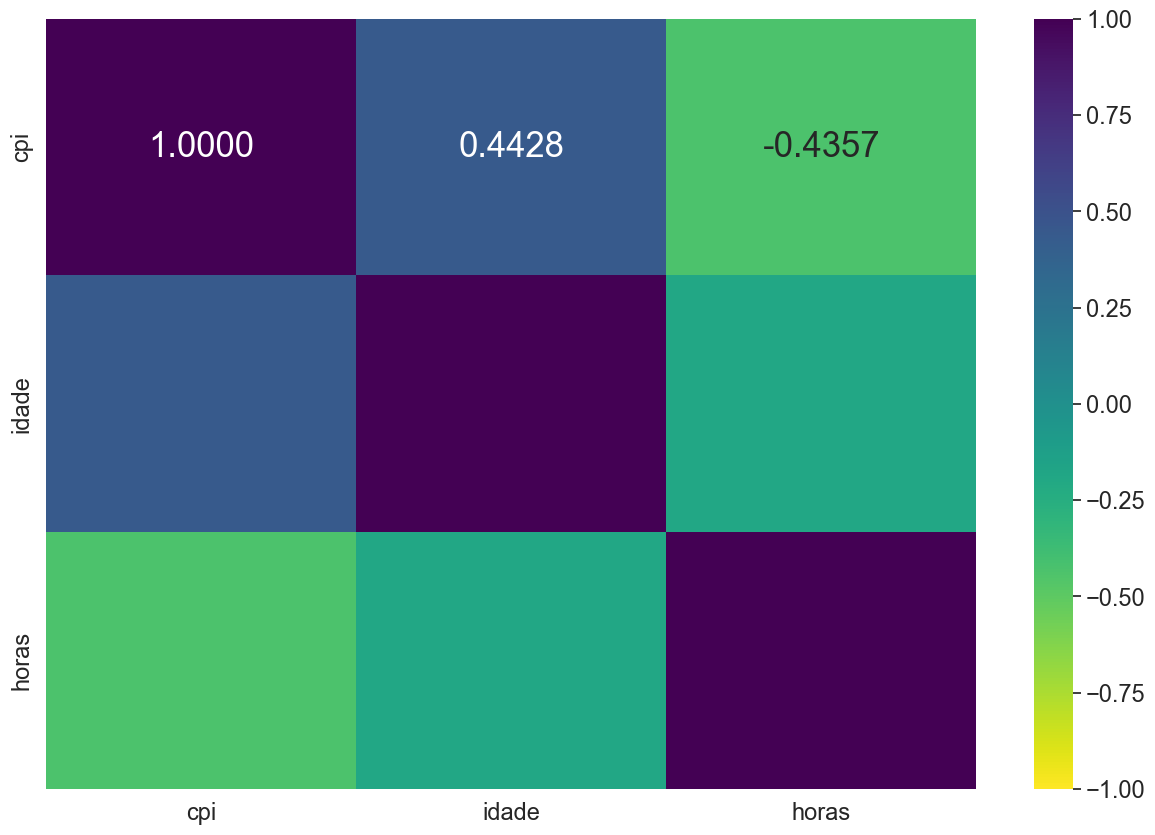

In [59]:
correlation_matrix = df_paises.iloc[:,1:4].corr()
correlation_matrix

# Mapa de calor com as correlações entre todas as variáveis quantitativas
plt.figure(figsize=(15, 10))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".4f",
                      cmap=plt.cm.viridis_r,
                      annot_kws={'size': 25}, vmin=-1, vmax=1)
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=17)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=17)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=17)
plt.show()

# Paletas de cores ('_r' reverte a sequência de cores):
# viridis
# inferno
# magma
# cividis
# coolwarm
# Blues
# Greens
# Reds

4.2 - Diagrama interessante (grafo) que mostra a inter-relação entre as variáveis e a magnitude das correlações entre elas

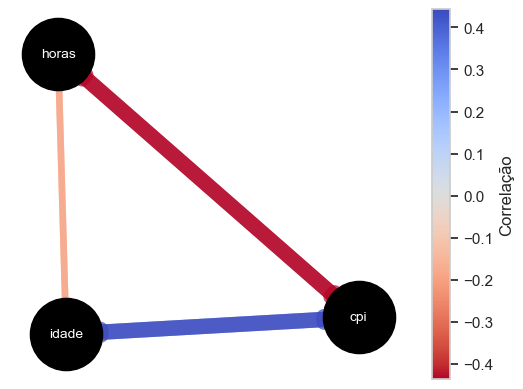

In [60]:
#variáveis e a magnitude das correlações entre elas

# conda install networkx
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Criação de um grafo direcionado
G = nx.DiGraph()

# Adição das variáveis como nós do grafo
for variable in correlation_matrix.columns:
    G.add_node(variable)

# Adição das arestas com espessuras proporcionais às correlações
for i, variable1 in enumerate(correlation_matrix.columns):
    for j, variable2 in enumerate(correlation_matrix.columns):
        if i != j:
            correlation = correlation_matrix.iloc[i, j]
            if abs(correlation) > 0:
                G.add_edge(variable1, variable2, weight=correlation)

# Obtenção da lista de correlações das arestas
correlations = [d["weight"] for _, _, d in G.edges(data=True)]

# Definição da dimensão dos nós
node_size = 2700

# Definição da cor dos nós
node_color = 'black'

# Definição da escala de cores das retas (correspondência com as correlações)
cmap = plt.colormaps.get_cmap('coolwarm_r')

# Criação de uma lista de espessuras das arestas proporcional às correlações
edge_widths = [abs(d["weight"]) * 25 for _, _, d in G.edges(data=True)]

# Criação do layout do grafo com maior distância entre os nós
pos = nx.spring_layout(G, k=0.75)  # k para controlar a distância entre os nós

# Desenho dos nós e das arestas com base nas correlações e espessuras
nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_color)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=correlations,
                       edge_cmap=cmap, alpha=0.7)

# Adição dos rótulos dos nós
labels = {node: node for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color='white')

# Ajuste dos limites dos eixos
ax = plt.gca()
ax.margins(0.1)
plt.axis("off")

# Criação da legenda com a escala de cores definida
smp = cm.ScalarMappable(cmap=cmap)
smp.set_array([min(correlations), max(correlations)])
cbar = plt.colorbar(smp, ax=ax, label='Correlação')

# Exibição do gráfico
plt.show()

4.3 - Matriz de correlações mais elaborada, com uso da função 'rcorr' do pacote 'pingouin'

In [61]:
correlation_matrix2 = pg.rcorr(df_paises, method='pearson',
                               upper='pval', decimals=6,
                               pval_stars={0.01: '***',
                                           0.05: '**',
                                           0.10: '*'})
correlation_matrix2

,cpi,idade,horas
cpi,-,***,***
idade,0.442838,-,
horas,-0.435724,-0.191748,-


*** 99% de nivel de significancia

 ** 95% de nivel de significancia
 
  * 90% de nivel de significancia

5 - Gráfico com distribuições das variáveis, scatters, valores das correlações e respectivas significâncias estatísticas


<Figure size 2000x1000 with 0 Axes>

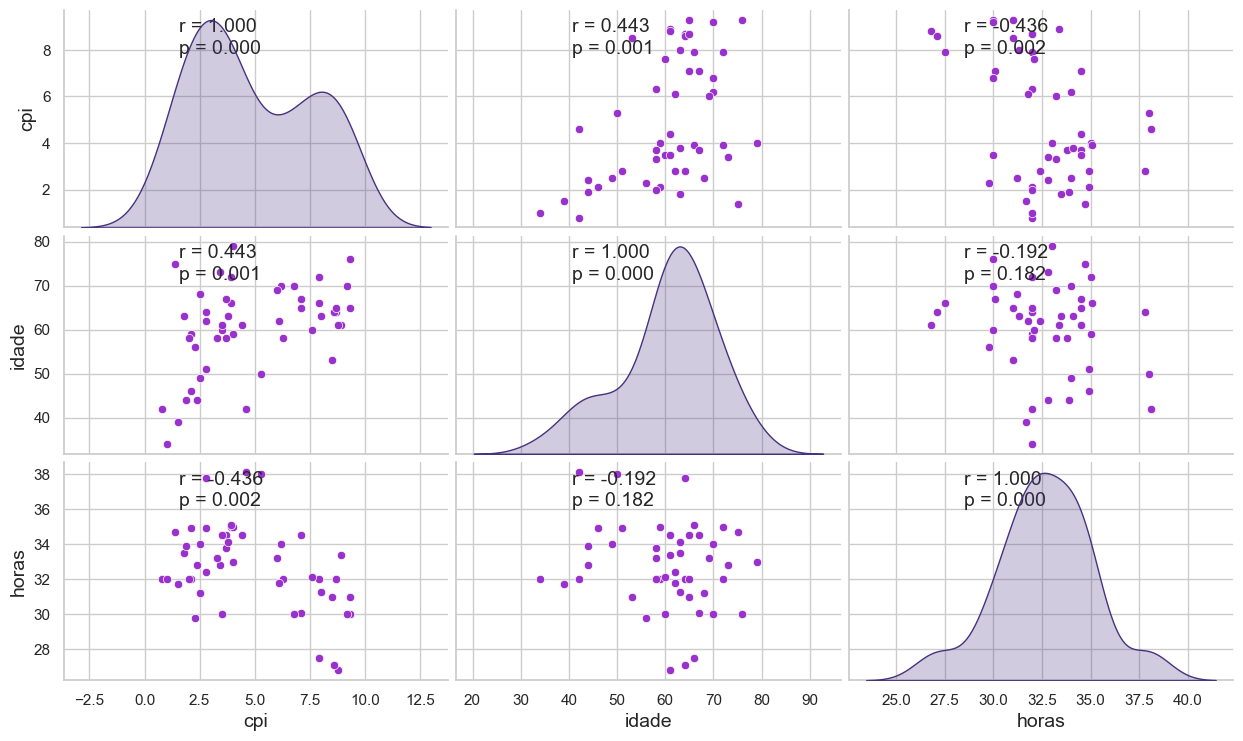

In [62]:
def corrfunc(x, y, **kws):
    (r, p) = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate("r = {:.3f}".format(r),
                xy=(.30, .9), xycoords=ax.transAxes, fontsize=14)
    ax.annotate("p = {:.3f}".format(p),
                xy=(.30, .8), xycoords=ax.transAxes, fontsize=14)

# Configuração do gráfico
sns.set(style="whitegrid", palette="viridis")

plt.figure(figsize=(20,10))
graph = sns.pairplot(df_paises, diag_kind="kde",
                     plot_kws={"color": "darkorchid"},
                     height=2.5, aspect=1.7)
graph.map(corrfunc)
for ax in graph.axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
plt.show()


6 - EEstimação de um modelo de regressão múltipla com as variáveis do dataframe 'df_paises'

In [63]:
# Estimando o modelo de regressão múltipla por OLS
modelo_paises = sm.OLS.from_formula("cpi ~ idade + horas", df_paises).fit()

6.1 - Parâmetros do 'modelo_paises'

In [64]:
modelo_paises.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cpi   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     11.26
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           0.000101
Time:                        21:10:04   Log-Likelihood:                -109.93
No. Observations:                  50   AIC:                             225.9
Df Residuals:                      47   BIC:                             231.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.9719      5.165      2.318      0.025       1.581      22.363
idade          0.0997      0.033      3.052      0.004       0.034       0.165
horas         -0.4013      0.135     -2.980      0.005      -0.672      -0.130
==============================================================================
Omnibus:                        3.389   Durbin-Watson:                   1.822
Prob(Omnibus):                  0.184   Jarque-Bera (JB):                1.762
Skew:                           0.131   Prob(JB):                        0.414
Kurtosis:                       2.119   Cond. No.                     1.13e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# cpi = 11.9719	+ (0.0997 x idade) + (-0.4013 x horas)

7 - Salvando os fitted values na base de dados

In [66]:
df_paises['cpifit'] = modelo_paises.fittedvalues
df_paises

,pais,cpi,idade,horas,cpifit
0,Argentina,3.9,72,35.0,5.103394
1,Australia,8.7,64,32.0,5.509820
2,Austria,7.9,72,32.0,6.307405
3,Belgium,7.1,67,30.1,6.571454
4,Brazil,4.0,59,35.0,3.807319
5,Canada,8.9,61,33.4,4.648854
6,Chile,6.2,70,34.0,5.305335
7,China,2.5,49,34.0,3.211674
8,Colombia,4.0,79,33.0,6.603955
9,Cyprus,6.3,58,32.0,4.911631


8 - Gráfico 3D com scatter e fitted values (superfície espacial) resultantes do 'modelo_paises', gerado em HTML e aberto no browser (figura 'EXEMPLO2_scatter3D_fitted.html' salva na pasta do curso)

In [67]:


# Dados observados ('scatter')
scatter = go.Scatter3d(
    x=df_paises['horas'],
    y=df_paises['idade'],
    z=df_paises['cpi'],
    mode='markers',
    marker=dict(
        size=10,
        color='darkorchid',
        opacity=0.7
    ),
    name='Observado'
)

# Ajuste do modelo
X = np.column_stack([
    np.ones(len(df_paises)),
    df_paises['horas'],
    df_paises['idade']
])

y = df_paises['cpi'].values

b0, b1, b2 = np.linalg.lstsq(X, y, rcond=None)[0]

# Definição da grade ('meshgrid')
horas_grid = np.linspace(df_paises['horas'].min(),
                          df_paises['horas'].max(), 50)

idade_grid = np.linspace(df_paises['idade'].min(),
                          df_paises['idade'].max(), 50)

H, I = np.meshgrid(horas_grid, idade_grid)

# Definição da superfície ('go.Surface')
Z = b0 + b1 * H + b2 * I

surface = go.Surface(
    x=horas_grid,
    y=idade_grid,
    z=Z,
    colorscale='Oranges',
    opacity=0.6,
    showscale=False,
    name='Superfície ajustada'
)

# Figura final
fig = go.Figure(data=[scatter, surface])

fig.update_layout(
    width=800,
    height=800,
    margin=dict(l=0, r=0, b=0, t=0),
    plot_bgcolor='white',
    scene=dict(
        xaxis=dict(
            title='horas',
            gridcolor='rgb(200,200,200)',
            backgroundcolor='whitesmoke'
        ),
        yaxis=dict(
            title='idade',
            gridcolor='rgb(200,200,200)',
            backgroundcolor='whitesmoke'
        ),
        zaxis=dict(
            title='cpi',
            gridcolor='rgb(200,200,200)',
            backgroundcolor='whitesmoke'
        )
    )
)

# Abre o arquivo HTML no browser
import webbrowser
fig.write_html('EXEMPLO2_scatter3D_fitted.html')
webbrowser.open('EXEMPLO2_scatter3D_fitted.html')


True